# ETL para Análise de Dados Financeiros

Este notebook implementa um processo de ETL (Extração, Transformação e Carga/Visualização) para dados financeiros sintéticos.

## 1. Extração (Extract)

Nesta etapa, carregamos os dados. Como não temos um arquivo de dados, vamos gerar dados sintéticos de séries temporais financeiras usando `pandas` e `numpy`.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo para os gráficos
sns.set_style("whitegrid")
pref = "abev"
data_path = f"data/{pref}.csv"

# Carregar dados
df = pd.read_csv(data_path, parse_dates=["Date"])

df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2000-01-03 00:00:00-05:00,0.161148,0.161148,0.161148,0.161148,0,0.0,0.0
1,2000-01-04 00:00:00-05:00,0.161148,0.161148,0.161148,0.161148,0,0.0,0.0
2,2000-01-05 00:00:00-05:00,0.161148,0.161148,0.161148,0.161148,0,0.0,0.0
3,2000-01-06 00:00:00-05:00,0.161148,0.161148,0.161148,0.161148,0,0.0,0.0
4,2000-01-07 00:00:00-05:00,0.161148,0.161148,0.161148,0.161148,0,0.0,0.0


## 2. Transformação (Transform)

Aqui, processamos e limpamos os dados. Vamos:
- Verificar valores ausentes.
- Calcular a média móvel do preço de fechamento.
- Calcular a variação percentual diária.

In [10]:
cols_to_drop = ["Dividends","Stock Splits"]

# Criar uma cópia para evitar SettingWithCopyWarning
df_transformed = df.copy()

df_transformed.dropna(inplace=True)
df_transformed = df_transformed.drop(columns=cols_to_drop)

# Garantir ordenação por data
df_transformed = df_transformed.sort_values("Date")

# Média móvel de 20 dias e retorno diário
df_transformed["Moving_Average_20"] = df_transformed["Close"].rolling(window=20, min_periods=1).mean()
df_transformed["Daily_Return"] = df_transformed["Close"].pct_change()

print(df_transformed.head())

                        Date      Open      High       Low     Close  Volume  \
0  2000-01-03 00:00:00-05:00  0.161148  0.161148  0.161148  0.161148       0   
1  2000-01-04 00:00:00-05:00  0.161148  0.161148  0.161148  0.161148       0   
2  2000-01-05 00:00:00-05:00  0.161148  0.161148  0.161148  0.161148       0   
3  2000-01-06 00:00:00-05:00  0.161148  0.161148  0.161148  0.161148       0   
4  2000-01-07 00:00:00-05:00  0.161148  0.161148  0.161148  0.161148       0   

   Moving_Average_20  Daily_Return  
0           0.161148           NaN  
1           0.161148           0.0  
2           0.161148           0.0  
3           0.161148           0.0  
4           0.161148           0.0  


## 3. Carga / Visualização (Load / Visualize)

Nesta etapa final, visualizamos os dados processados para análise.

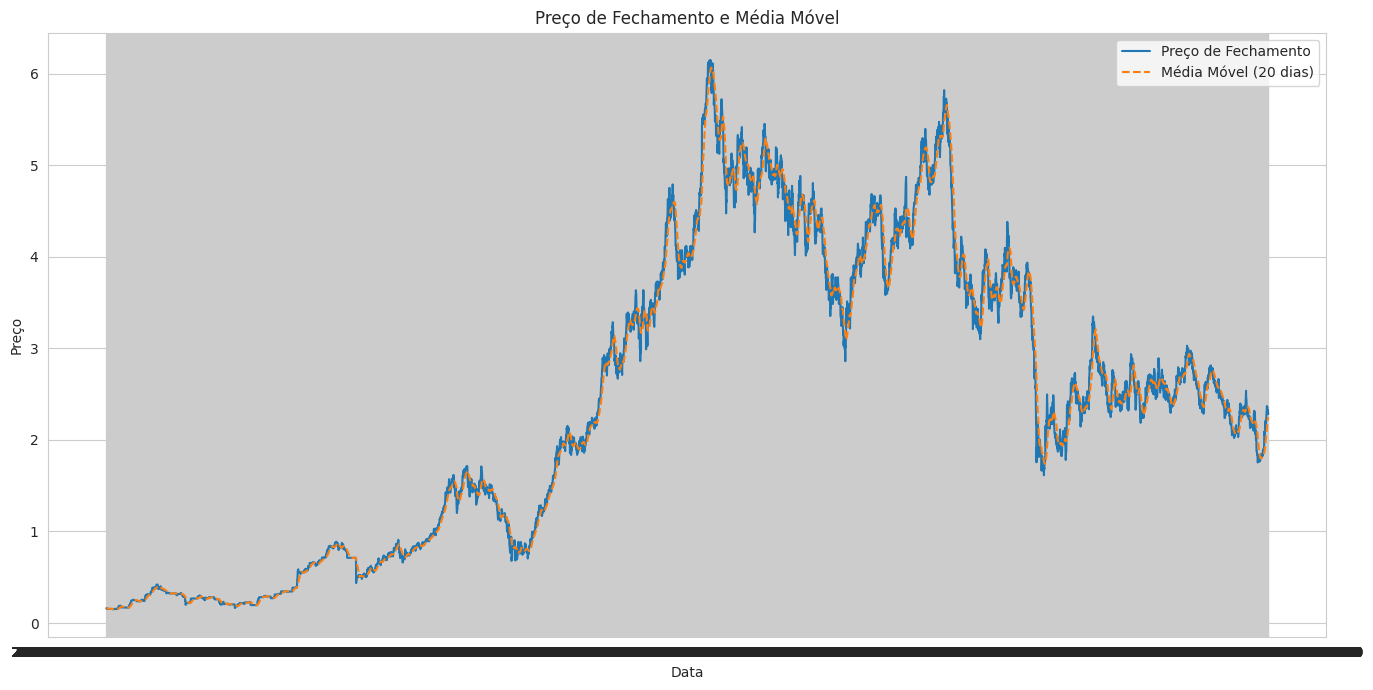

In [11]:
# Gráfico 1: Preço de Fechamento e Média Móvel
plt.figure(figsize=(14, 7))
plt.plot(df_transformed['Date'], df_transformed['Close'], label='Preço de Fechamento')
plt.plot(df_transformed['Date'], df_transformed['Moving_Average_20'], label='Média Móvel (20 dias)', linestyle='--')
plt.title('Preço de Fechamento e Média Móvel')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.tight_layout()
plt.show()

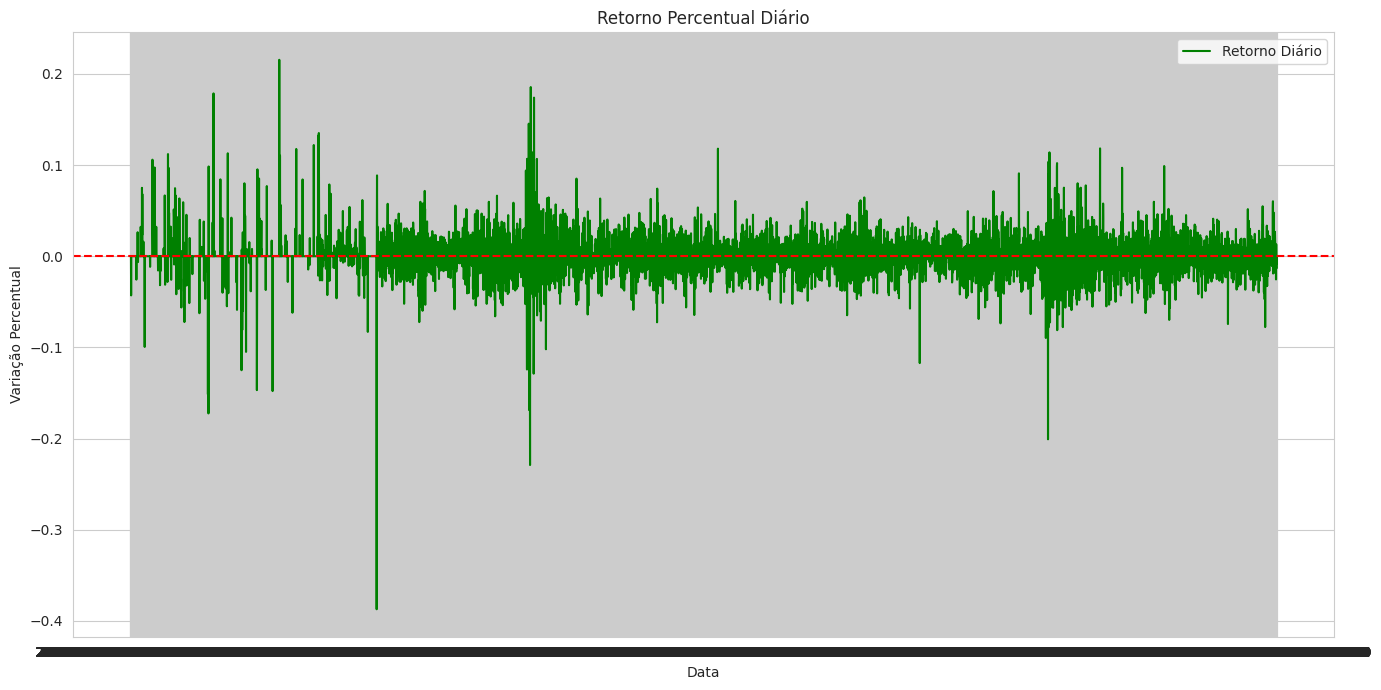

In [12]:
# Gráfico 2: Retorno Diário
plt.figure(figsize=(14, 7))
plt.plot(df_transformed['Date'], df_transformed['Daily_Return'], label='Retorno Diário', color='green')
plt.title('Retorno Percentual Diário')
plt.xlabel('Data')
plt.ylabel('Variação Percentual')
plt.axhline(0, color='red', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

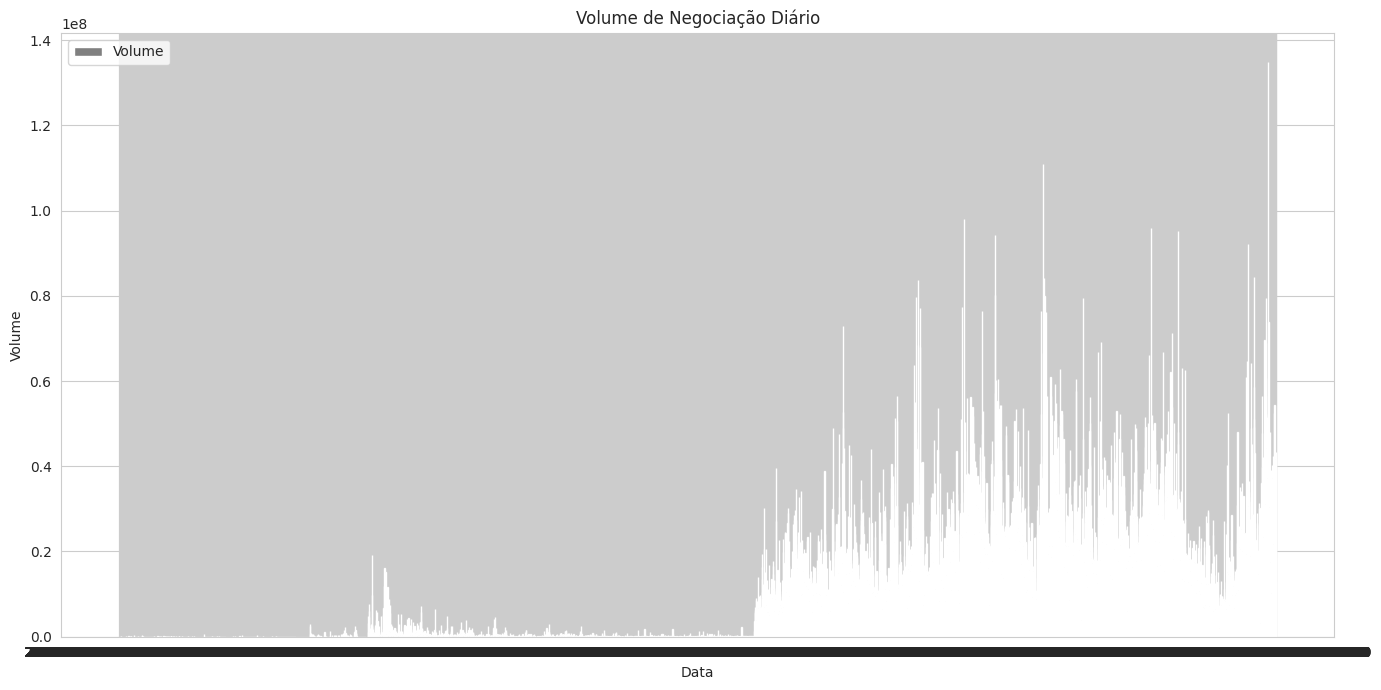

In [13]:
# Gráfico 3: Volume de Negociação
plt.figure(figsize=(14, 7))
plt.bar(df_transformed['Date'], df_transformed['Volume'], label='Volume', color='gray')
plt.title('Volume de Negociação Diário')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
df_transformed.describe()

,Open,High,Low,Close,Volume,Moving_Average_20,Daily_Return
count,6348.000000,6348.000000,6348.000000,6348.000000,6.348000e+03,6348.000000,6347.000000
mean,2.392179,2.419931,2.364758,2.392665,9.842077e+06,2.389467,0.000678
std,1.632051,1.649835,1.614053,1.632308,1.372533e+07,1.631821,0.022639
min,0.150273,0.150273,0.150273,0.150273,0.000000e+00,0.152300,-0.387143
25%,0.794418,0.801174,0.785961,0.795432,4.850000e+04,0.796105,-0.008198
50%,2.357624,2.389452,2.327906,2.360071,7.012500e+05,2.363146,0.000000
75%,3.773459,3.821421,3.728825,3.772217,1.707435e+07,3.769222,0.009654
max,6.172008,6.179985,6.122813,6.145416,1.349556e+08,6.065441,0.215422


In [15]:
df_transformed.info()

<class 'pandas.DataFrame'>
RangeIndex: 6348 entries, 0 to 6347
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               6348 non-null   str    
 1   Open               6348 non-null   float64
 2   High               6348 non-null   float64
 3   Low                6348 non-null   float64
 4   Close              6348 non-null   float64
 5   Volume             6348 non-null   int64  
 6   Moving_Average_20  6348 non-null   float64
 7   Daily_Return       6347 non-null   float64
dtypes: float64(6), int64(1), str(1)
memory usage: 396.9 KB


In [16]:
# Calcular o ponto de divisão (70% dos dados)
split_point = int(len(df) * 0.7)

# Dividir o DataFrame
train_df = df_transformed.iloc[:split_point]
test_df = df_transformed.iloc[split_point:]

# Salvar os DataFrames em arquivos CSV
train_df.to_csv(f'data/{pref}_transformed_train.csv', index=False)
test_df.to_csv(f'data/{pref}_transformed_test.csv', index=False)

print(f"Dados de treino salvos em 'data/{pref}_transformed_train.csv' com {len(train_df)} registros.")
print(f"Dados de teste salvos em 'data/{pref}_transformed_test.csv' com {len(test_df)} registros.")

Dados de treino salvos em 'data/abev_transformed_train.csv' com 4443 registros.
Dados de teste salvos em 'data/abev_transformed_test.csv' com 1905 registros.
